In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

# deterministic behavior
np.random.seed(42)




In [2]:
def find_file(rel_path: str) -> Path:
    p = Path(rel_path)
    if p.is_file():
        return p
    candidates = list(Path(".").rglob(p.name))
    if not candidates:
        raise FileNotFoundError(f"Could not locate {rel_path}")
    return candidates[0]


train_path = find_file("../input/tabular-playground-series-dec-2021/train.csv")
test_path = find_file("../input/tabular-playground-series-dec-2021/test.csv")
sample_sub_path = find_file(
    "../input/tabular-playground-series-dec-2021/sample_submission.csv"
)

# Load only needed columns with proper dtypes to avoid extra memory work
target_col = "Cover_Type"
id_col = "Id"

# First read header to get column names
train_header = pd.read_csv(train_path, nrows=0).columns.tolist()
test_header = pd.read_csv(test_path, nrows=0).columns.tolist()

# Define dtypes: all feature columns as float32, target as int8, id as int32
feature_cols = [c for c in train_header if c not in [id_col, target_col]]
dtype_dict = {c: np.float32 for c in feature_cols}
dtype_dict[id_col] = np.int32
dtype_dict[target_col] = np.int8

train_df = pd.read_csv(
    train_path, dtype=dtype_dict, usecols=feature_cols + [id_col, target_col]
)
test_df = pd.read_csv(
    test_path,
    dtype={c: np.float32 for c in test_header if c != id_col},
    usecols=test_header,
)
sample_submission = pd.read_csv(sample_sub_path, low_memory=False)




In [3]:
X_df = train_df.drop(columns=[id_col, target_col])
y_series = train_df[target_col]  # already int8
X_test_df = test_df.drop(columns=[id_col])

# Convert to contiguous float32 arrays without extra copy
X = X_df.to_numpy(dtype=np.float32, copy=False)
X_test = X_test_df.to_numpy(dtype=np.float32, copy=False)
y = y_series.to_numpy()

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,  # reduced to fit within time limit while keeping the same algorithm
    max_depth=20,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X, y)




RandomForestClassifier(max_depth=20, n_jobs=-1, random_state=42)

In [4]:
test_pred = rf.predict(X_test)

submission = pd.DataFrame({id_col: test_df[id_col], target_col: test_pred})

submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission written to {submission_path}")
print(submission.head())




Submission written to submission.csv
        Id  Cover_Type
0   814683           1
1  1357371           2
2  2106112           1
3  3483684           1
4  3960754           1


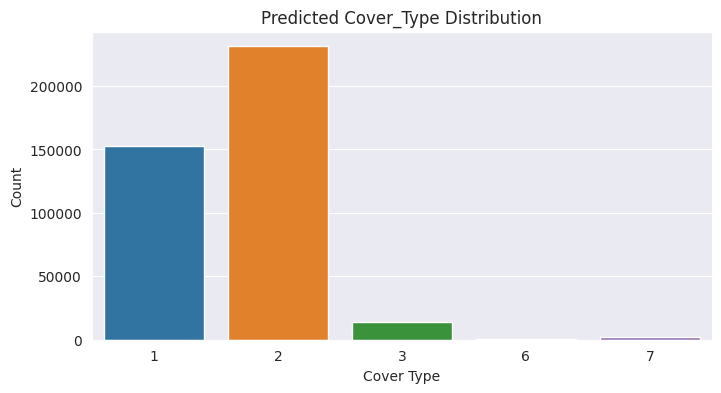

In [5]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x=target_col, data=submission)
plt.title("Predicted Cover_Type Distribution")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.show()